In [9]:
import torch
import plotly.express as px
import plotly.graph_objects as go
from pprint import pprint
import pandas
from copy import copy
from plotly.subplots import make_subplots
from matplotlib.gridspec import GridSpec

outputs = torch.load("../../databases/results/posebusters_all_df.pt", weights_only=False)
result_dfs = outputs["bust_df"]
tools_ordered = ["Vina"]
result_dfs = {tool: result_dfs[tool][0] for tool in tools_ordered}
cols = [
    "ligand_detail",
    "blind_docking",
    "bond_lengths",
    "bond_angles",
    "aromatic_ring_maximum_distance_from_plane",
    "double_bond_maximum_distance_from_plane",
    "internal_steric_clash",
    "minimum_distance_to_protein",
    "rmsd",
    "centroid_distance",
    "volume_overlap_protein"
]

targets = [
    "rmsd",
    "centroid_distance",
    "bond_lengths",
    "bond_angles",
    "aromatic_ring_maximum_distance_from_plane",
    "double_bond_maximum_distance_from_plane",
    "internal_steric_clash",
    "minimum_distance_to_protein",
]
final_df_data = {}
for c in targets:
    final_df_data[c] = []
    final_df_data[f"{c}_std"] = []

tool_names = []

# cols for final df
tools = []
counts = []
failed_names = []
for i, (tool, full_results) in enumerate(result_dfs.items()):
    print(full_results.tool)
    assert all(full_results.tool == tool), f"not all results come from {tool}"
    tool_names.append(tool)
    results = full_results.loc[
        (full_results.mol_pred_loaded) &
        (full_results.mol_true_loaded) &
        (full_results.mol_cond_loaded) &  # generally, all types of molecules are loaded
        (~full_results["rmsd_≤_2å"].isna()) &
        (~full_results.rmsd.isna()) &
        (~full_results.centroid_distance.isna())&
        (full_results.sanitization), 
        cols
    ]
    result_dfs[tool] = results

file                                                 molecule                                             position
../../databases/Vina/outputs/7M41_YQG/7M41_YQG1.sdf  ../../databases/Vina/outputs/7M41_YQG/7M41_YQG1.pdb  0           Vina
../../databases/Vina/outputs/8BPL_CP/8BPL_CP1.sdf    ../../databases/Vina/outputs/8BPL_CP/8BPL_CP1.pdb    0           Vina
../../databases/Vina/outputs/7A9E_R4W/7A9E_R4W1.sdf  ../../databases/Vina/outputs/7A9E_R4W/7A9E_R4W1.pdb  0           Vina
../../databases/Vina/outputs/7MGT_ZD4/7MGT_ZD41.sdf  ../../databases/Vina/outputs/7MGT_ZD4/7MGT_ZD41.pdb  0           Vina
../../databases/Vina/outputs/7BCP_GCO/7BCP_GCO1.sdf  ../../databases/Vina/outputs/7BCP_GCO/7BCP_GCO1.pdb  0           Vina
                                                                                                                      ... 
../../databases/Vina/outputs/7UF2_5SP/7UF2_5SP1.sdf  ../../databases/Vina/outputs/7UF2_5SP/7UF2_5SP1.pdb  0           Vina
../../databases/Vina/out

In [10]:
# Violin plot
tools = list(result_dfs.keys())
fig_data = []
result_dfs_orders = {
    "Vina": result_dfs["Vina"],
}
for i,(tool, df_full) in enumerate(result_dfs_orders.items()):
    df = copy(df_full.loc[
        (df_full.rmsd < 20) &
        (df_full.centroid_distance < 20)
    ])
    fig_data.extend([
        go.Violin(
            y=df.rmsd.values,
            x = [tool]*(len(df)),
            side="negative",
            legendgroup="RMSD",
            name="RMSD",
            showlegend=i==0,
            points="all",
            jitter=0.1,
            line_color="blue",
        ),
        go.Violin(
            y=df.centroid_distance.values,
            x = [tool]*len(df),
            side= "positive",
            name="Centroid distance",
            legendgroup="Centroid distance",
            line_color="red",
            showlegend=i==0,
            points=False,
        )
    ])
fig = go.Figure(fig_data)
fig.update_yaxes(range=[-5,25], title={"text": "Ångström"})
fig.update_layout(
    font_size=23,
    violingap=0.5, violinmode="overlay",
    margin=dict(t=0,b=0,l=50,r=0),
    width=450,
    height=450,
    legend = {
        "orientation": "h",
        "yanchor": "bottom",
        "xanchor": "right",
        "y":1.02,
        "x":1
    },
)
fig.show()
fig.write_image("./figures/violin.jpg", width=450, height=450)

['Vina']
{'full': [57.597171783447266]}


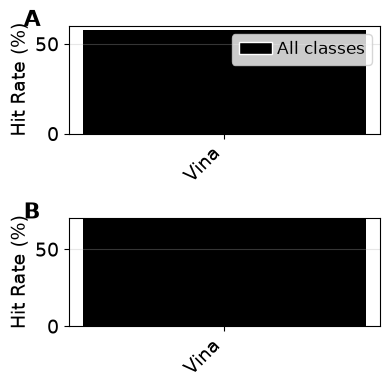

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing data gathering code remains the same
tools = list(result_dfs_orders.keys())
print(tools)
hitrates = {
    "all": {
        "2": {
            "full": [],
        },
        "5": {
            "full": [],
        },
    },
}

for i, (tool, all_df) in enumerate(result_dfs.items()):
    for docking_mode in ["all"]:
        docking_regime_df = all_df
        df = all_df
        for threshold in ["2", "5"]:
            hitcount = torch.tensor(df.rmsd.values < float(threshold), dtype=torch.bool).float().sum()
            hitrate = (hitcount/df.shape[0])*100
            hitrates[docking_mode][threshold]["full"].append(hitrate.item())

# Colors for enzyme classes
class_colors = {
    'A': "#4EC218",  # Coral red
    'B': "#8AA6FF",  # Turquoise
    'C': "#0026FF"   # Sky blue
}
def plot_docking_analysis(hitrates):
    """
    Plot docking analysis results in 4 subplots.
    
    Parameters:
    -----------
    hitrates : dict
        Dictionary with structure {'TBD':{'A':{'2':[], '5':[]}, ...}, 'PBD':{...}}
    enz_class_proportions : dict
        Dictionary with structure {'TBD':{'A':[], 'B':[], 'C':[]}, 'PBD':{...}}
    tools : list, optional
        List of tool names. If None, inferred from data length.
    """
    

    # ============================================================
    # Subplot 3: Hit Rates at 2Å Threshold
    # ============================================================
    fig, (ax3,ax4) = plt.subplots(2,1,figsize=(4, 4))
    
    # Grouped bars for TBD vs PBD for each tool
    grouped_hitrates = {enz_class: hitrates["all"]["2"][enz_class] for enz_class in ["full"]}
    print(grouped_hitrates)
    ax3.grouped_bar(
        grouped_hitrates, 
        tick_labels=tools, 
        group_spacing=1,
        colors=["black"])
    
    # Add dummy bars for legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="black", edgecolor='white', label='All classes'),
    ]
    
    ax3.set_ylabel('Hit Rate (%)', fontsize=14)
    ax3.set_xticklabels(tools, rotation=45, ha='right')
    ax3.legend(
        handles=legend_elements, 
        fontsize=12, 
        loc='upper right', 
        ncol=4,
        handletextpad=0.3
    )
    ax3.tick_params(axis="both", labelsize=14)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([0,60])

    # ============================================================
    # Subplot 4: Hit Rates at 5Å Threshold
    # ============================================================
    
    # Grouped bars for TBD vs PBD for each tool
    grouped_hitrates = {enz_class: hitrates["all"]["5"][enz_class] for enz_class in ["full"]}
    ax4.grouped_bar(
        grouped_hitrates, 
        tick_labels=tools, 
        group_spacing=1,
        colors=["black"])
    # ax4.set_xticks(x)
    ax4.set_ylabel('Hit Rate (%)', fontsize=14)
    ax4.set_xticklabels(tools, rotation=45, ha='right')
    ax4.tick_params(axis="both", labelsize=14)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim([0,70])

    annotation_labels = ['A', 'B']
    annotation_positions = [
        (-0.09, 0.95),  # A - top-left
        (-0.09, 0.95),  # B - top-right
    ]
    axes = [ax3, ax4]
    for i, (ax, (x_pos, y_pos), label) in enumerate(zip(axes, annotation_positions, annotation_labels)):
        ax.text(x_pos, y_pos, label, transform=ax.transAxes, 
                fontsize=16, fontweight='bold', va='bottom', ha='right')
    
    # Adjust layout
    fig.subplots_adjust(
        wspace=0.2,
        hspace=0.25,
        bottom=0.35,
        top=0.95,
        left=0.09,
        right=0.99
    )
    
    # Save figure
    fig.tight_layout()
    fig.savefig(f"figures/hitrates.jpg", dpi=600)
    fig.show()
    
    return fig

fig = plot_docking_analysis(hitrates)

In [ ]:
criteria = "volume_overlap_protein"

# retrieve TBD data:
tools_ordered = ["Vina"]
data_tbd = [df.loc[df.blind_docking, [criteria]].values*100 for df in result_dfs.values()][0]

# make the figure:
fig, ax = plt.subplots(figsize=(4,4))

# TBD graph:
bars = ax.boxplot(
    data_tbd,
    patch_artist=True,
    notch=True,
    showfliers=False
)
    # Add jitter to x-position
x_jitter = np.random.normal(0.6, 0.01, len(data_tbd))
ax.scatter(x_jitter, data_tbd, alpha=0.5, color='blue', s=20, zorder=3)
ax.set_xticklabels(tools_ordered, rotation=20, fontsize=14)

ax.set_ylabel("Percentage", fontsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("./figures/boxplot_volume_overlap.jpg", dpi=600)
plt.show()
tools_ordered = [
    "Boltz-2", "AlphaFold3", "DynamicBind", 
    "DiffDock", "TankBind", "NeuralPLexer", "EquiBind", "DPL", "Vina"]